# Notebook 7 — Criticalidad en Redes Cerebrales

**Prerequisito:** Notebook 02 ejecutado. Archivos `outputs/fc_matrices/{MRI_ID}_fc_z.npy` y `outputs/eligible_fc_subjects.csv` deben existir.

## Contexto metodológico

**¿Por qué umbral proporcional y no Fisher-z?**  
Los archivos `_fc_z.npy` muestran variación enorme entre sitios en la magnitud absoluta de las correlaciones (densidad a umbral 0.20 varía de 0.11 a 0.53 según el sitio). Usar un umbral Fisher-z fijo confundiría las diferencias topológicas con el efecto de sitio en conectividad absoluta. El umbral proporcional (`PROP = 0.10`) iguala la densidad al 10% para todos los sujetos, haciendo comparables las *topologías* independientemente de la intensidad total de señal. Este es el estándar en la literatura de criticalidad en neuroimagen de datos heterogéneos.

**Restricción computacional:** Las simulaciones estocásticas (avalanchas, branching ratio) corren sobre una **única matriz de adyacencia promedio por grupo** (CN, AD, FTD). Los análisis determinísticos (λ₁, percolación) corren por sujeto individual.

## Sección 0 — Setup e imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from pathlib import Path
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from itertools import combinations

try:
    import powerlaw
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'powerlaw', '-q'])
    import powerlaw

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

COLORS   = {'CN': '#185fa5', 'AD': '#e24b4a', 'FTD': '#ef9f27'}
DIAG_ORD = ['CN', 'AD', 'FTD']

# ── Umbral proporcional ───────────────────────────────────────────────────────
# Top PROP fracción de conexiones más fuertes. Iguala densidad entre sujetos
# compensando el efecto de sitio en la magnitud absoluta de las correlaciones.
PROP = 0.10   # 10 % de densidad — estándar en literatura de criticalidad fMRI

FIG_DIR = Path('figures/03_criticalidad')
RES_DIR = Path('results')
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Densidad objetivo: {PROP:.0%}')
print('Setup completo.')

Densidad objetivo: 10%
Setup completo.


In [2]:
FC_DIR   = Path('outputs/fc_matrices')
eligible = pd.read_csv('outputs/eligible_fc_subjects.csv')

def threshold_proportional(fc_z: np.ndarray, prop: float = PROP) -> np.ndarray:
    """Conserva el top `prop` de conexiones (upper-triangle) más fuertes."""
    mat = fc_z.copy()
    np.fill_diagonal(mat, 0)
    triu_idx = np.triu_indices(mat.shape[0], k=1)
    thr = np.percentile(mat[triu_idx], (1 - prop) * 100)
    B = (mat >= thr).astype(float)
    return np.maximum(B, B.T)

# Cargar FC-z por sujeto y construir matrices promedio por grupo
fc_by_group  = {g: [] for g in DIAG_ORD}
subject_meta = []

for _, row in eligible.iterrows():
    diag = row['diagnosis']
    if diag not in DIAG_ORD:
        continue
    p = FC_DIR / f"{row['MRI_ID']}_fc_z.npy"
    if not p.exists():
        continue
    fc_by_group[diag].append(np.load(p))
    subject_meta.append({'MRI_ID': row['MRI_ID'], 'diagnosis': diag,
                         'Age': row['Age'], 'site': row['site']})

meta_df = pd.DataFrame(subject_meta)

# Matriz promedio: promediar FC-z continua → binarizar proporcional
fc_mean  = {g: np.mean(fc_by_group[g], axis=0) for g in DIAG_ORD}
adj_mean = {g: threshold_proportional(fc_mean[g]) for g in DIAG_ORD}

print(f'Sujetos cargados: {len(meta_df)}')
print(meta_df['diagnosis'].value_counts())
print()
for g in DIAG_ORD:
    dens = adj_mean[g].sum() / 2 / (116 * 115 / 2)
    deg  = adj_mean[g].sum(axis=0).mean()
    print(f'{g} (n={len(fc_by_group[g])}): densidad={dens:.4f}  grado_medio={deg:.1f}')

Sujetos cargados: 1327
diagnosis
CN     555
AD     468
FTD    304
Name: count, dtype: int64

CN (n=555): densidad=0.1000  grado_medio=11.5
AD (n=468): densidad=0.1000  grado_medio=11.5
FTD (n=304): densidad=0.1000  grado_medio=11.5


---
## Sección 1 — Autovalor máximo (λ₁) y rango dinámico

El autovalor máximo de la matriz de adyacencia **λ₁** es el indicador espectral de criticalidad para modelos de contagio simple (SIS, branching process):

| Régimen | Criterio | Interpretación |
|---|---|---|
| Subcrítico | λ₁ × p < 1 | La actividad se extingue |
| Crítico | λ₁ × p = 1 | Propagación sostenida |
| Supercrítico | λ₁ × p > 1 | Actividad explosiva |

**Qué esperar en redes de 116 regiones al 10% de densidad:**  
Con grado medio ≈ 11.5, λ₁ se sitúa estructuralmente entre 15 y 25 para redes con hubs (muy por encima del punto crítico teórico λ₁ = 1). Esto es **esperado** y no indica patología — el punto crítico del modelo es λ₁ = 1 con p = 1. La comparación relevante es **entre grupos**: menor λ₁ → menor supercriticalidad → mayor capacidad dinámica teórica. Para contextualizar cuánto se alejan del azar, se calcula **λ₁_norm = λ₁_brain / λ₁_ER** donde λ₁_ER proviene de grafos Erdős-Rényi con la misma densidad (100 realizaciones por grupo).

In [3]:
# λ₁ por sujeto individual
lambda1_records = []

for _, row in meta_df.iterrows():
    fc_z = np.load(FC_DIR / f"{row['MRI_ID']}_fc_z.npy")
    B    = threshold_proportional(fc_z)
    lam1 = np.linalg.eigvalsh(B)[-1]   # eigvalsh devuelve en orden ascendente
    lambda1_records.append({
        'MRI_ID': row['MRI_ID'], 'diagnosis': row['diagnosis'],
        'Age': row['Age'], 'lambda1': lam1,
    })

lambda1_df = pd.DataFrame(lambda1_records)

# λ₁ para matrices promedio por grupo
lambda1_mean = {g: np.linalg.eigvalsh(adj_mean[g])[-1] for g in DIAG_ORD}

print('λ₁ por grupo (sujetos individuales, PROP=10%)')
print(lambda1_df.groupby('diagnosis')['lambda1'].describe().round(3))
print('\nλ₁ matrices promedio grupales:')
for g in DIAG_ORD:
    print(f'  {g}: λ₁ = {lambda1_mean[g]:.4f}')

λ₁ por grupo (sujetos individuales, PROP=10%)
           count    mean    std     min     25%     50%     75%     max
diagnosis                                                              
AD         468.0  20.229  2.676  14.109  18.288  20.074  21.930  29.291
CN         555.0  20.976  3.099  14.389  18.752  20.752  22.816  29.548
FTD        304.0  20.981  2.973  14.424  18.791  20.721  23.129  30.874

λ₁ matrices promedio grupales:
  CN: λ₁ = 20.2577
  AD: λ₁ = 18.1297
  FTD: λ₁ = 19.5230


In [4]:
# ── Null model ER: λ₁ esperado en grafos aleatorios con misma densidad ────────
# Contexto: λ₁_brain / λ₁_ER > 1 indica concentración de conectividad en hubs
# respecto a una red aleatoria equivalente. λ₁_norm compara topología entre grupos.

def er_lambda1_null(density: float, n: int = 116, n_null: int = 100, seed: int = 42):
    """λ₁ promedio y SD de grafos ER con misma N y densidad."""
    rng = np.random.default_rng(seed)
    lambdas = []
    for _ in range(n_null):
        G = nx.erdos_renyi_graph(n, density, seed=int(rng.integers(1e6)))
        A = nx.to_numpy_array(G, dtype=float)
        np.fill_diagonal(A, 0)
        lambdas.append(np.linalg.eigvalsh(A)[-1])
    return float(np.mean(lambdas)), float(np.std(lambdas))

# Densidad de las matrices promedio grupales (debería ser ≈ PROP para todas)
er_null = {}
for g in DIAG_ORD:
    dens_g = adj_mean[g].sum() / 2 / (116 * 115 / 2)
    mu_er, sd_er = er_lambda1_null(dens_g)
    er_null[g] = {'mu': mu_er, 'sd': sd_er, 'density': dens_g,
                  'lambda1_norm': lambda1_mean[g] / mu_er}
    print(f'{g}: λ₁_brain={lambda1_mean[g]:.3f}  λ₁_ER={mu_er:.3f}±{sd_er:.3f}  '
          f'λ₁_norm={lambda1_mean[g]/mu_er:.3f}')

# λ₁_norm por sujeto (usando el λ₁_ER del propio grupo)
lambda1_df['lambda1_norm'] = lambda1_df.apply(
    lambda r: r['lambda1'] / er_null[r['diagnosis']]['mu'], axis=1
)

print('\nλ₁_norm > 1 → red más hub-like que aleatoria con misma densidad')
print(lambda1_df.groupby('diagnosis')['lambda1_norm'].describe().round(3))

CN: λ₁_brain=20.258  λ₁_ER=12.427±0.404  λ₁_norm=1.630
AD: λ₁_brain=18.130  λ₁_ER=12.427±0.404  λ₁_norm=1.459
FTD: λ₁_brain=19.523  λ₁_ER=12.427±0.404  λ₁_norm=1.571

λ₁_norm > 1 → red más hub-like que aleatoria con misma densidad
           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
AD         468.0  1.628  0.215  1.135  1.472  1.615  1.765  2.357
CN         555.0  1.688  0.249  1.158  1.509  1.670  1.836  2.378
FTD        304.0  1.688  0.239  1.161  1.512  1.667  1.861  2.484


In [5]:
def simulate_response(A: np.ndarray, h_vals: np.ndarray, n_steps: int = 500) -> np.ndarray:
    """Respuesta estacionaria F(h) del modelo SIS de campo medio.
    F_i = 1 - exp(-h - A @ F)  →  iteración hasta convergencia.
    """
    n = A.shape[0]
    responses = np.zeros(len(h_vals))
    for i, h in enumerate(h_vals):
        F = np.zeros(n)
        for _ in range(n_steps):
            F_new = 1 - np.exp(-h - A @ F)
            if np.max(np.abs(F_new - F)) < 1e-9:
                break
            F = F_new
        responses[i] = F.mean()
    return responses

def dynamic_range(h_vals, F):
    """Δ = 10·log10(h_0.9 / h_0.1) — rango de h entre 10% y 90% de respuesta máx."""
    F_norm = (F - F.min()) / (F.max() - F.min() + 1e-12)
    idx01  = np.searchsorted(F_norm, 0.1)
    idx09  = np.searchsorted(F_norm, 0.9)
    if idx01 >= len(h_vals) or idx09 >= len(h_vals) or h_vals[idx01] <= 0:
        return np.nan
    return 10 * np.log10(h_vals[idx09] / h_vals[idx01])

h_vals     = np.logspace(-5, 1, 300)
delta_vals = {}

print('Rango dinámico Δ (dB)  — mayor Δ → más cercano al punto crítico')
for g in DIAG_ORD:
    F   = simulate_response(adj_mean[g], h_vals)
    dyn = dynamic_range(h_vals, F)
    delta_vals[g] = dyn
    print(f'  {g}: Δ = {dyn:.2f} dB  | λ₁ = {lambda1_mean[g]:.4f}  | λ₁_norm = {er_null[g]["lambda1_norm"]:.3f}')

Rango dinámico Δ (dB)  — mayor Δ → más cercano al punto crítico
  CN: Δ = 16.05 dB  | λ₁ = 20.2577  | λ₁_norm = 1.630
  AD: Δ = 17.46 dB  | λ₁ = 18.1297  | λ₁_norm = 1.459
  FTD: Δ = 16.25 dB  | λ₁ = 19.5230  | λ₁_norm = 1.571


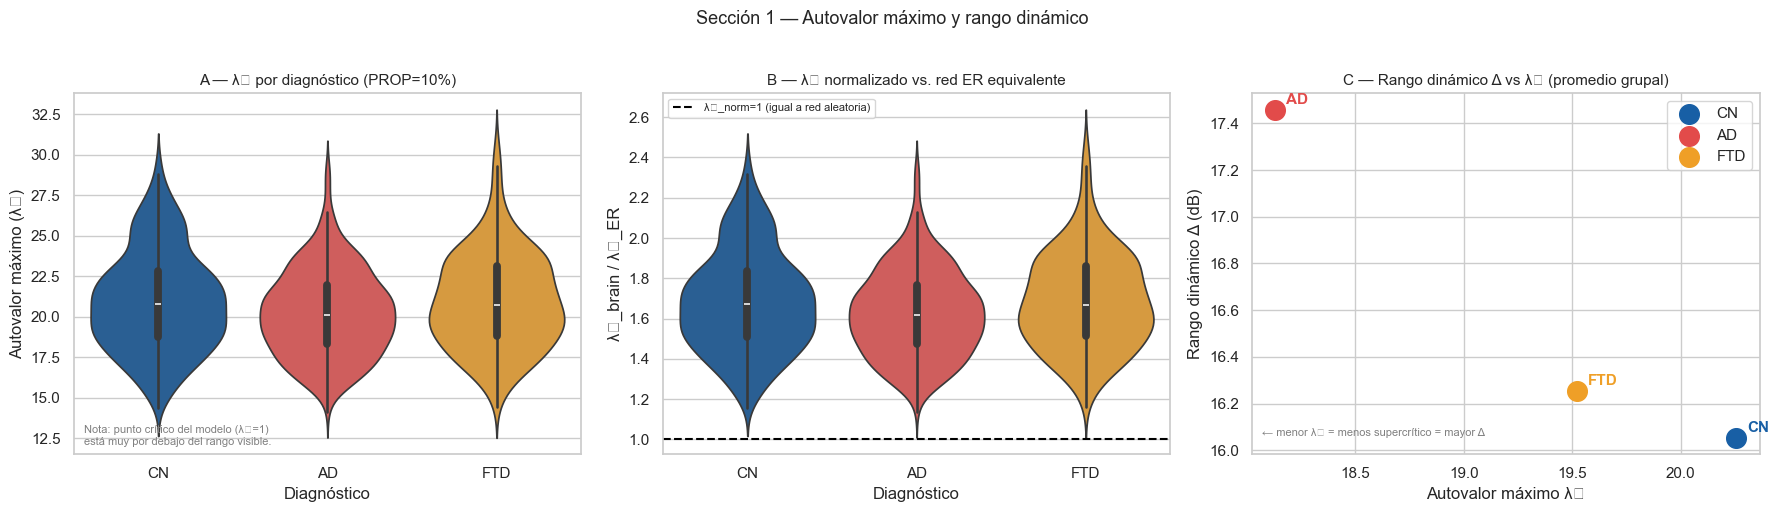

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: violinplot λ₁ individual
ax = axes[0]
sub = lambda1_df[lambda1_df.diagnosis.isin(DIAG_ORD)]
sns.violinplot(data=sub, x='diagnosis', y='lambda1', order=DIAG_ORD,
               palette=COLORS, inner='box', ax=ax)
# Línea λ₁=1 está fuera del rango visible — anotar en vez de trazar
ax.set_title('A — λ₁ por diagnóstico (PROP=10%)', fontsize=11)
ax.set_xlabel('Diagnóstico'); ax.set_ylabel('Autovalor máximo (λ₁)')
ax.text(0.02, 0.02, 'Nota: punto crítico del modelo (λ₁=1)\nestá muy por debajo del rango visible.',
        transform=ax.transAxes, fontsize=8, color='gray',
        verticalalignment='bottom')

# Panel B: λ₁ normalizado (brain / ER)
ax = axes[1]
sns.violinplot(data=sub, x='diagnosis', y='lambda1_norm', order=DIAG_ORD,
               palette=COLORS, inner='box', ax=ax)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5,
           label='λ₁_norm=1 (igual a red aleatoria)')
ax.set_title('B — λ₁ normalizado vs. red ER equivalente', fontsize=11)
ax.set_xlabel('Diagnóstico'); ax.set_ylabel('λ₁_brain / λ₁_ER')
ax.legend(fontsize=8)

# Panel C: Δ vs λ₁ (matrices promedio)
ax = axes[2]
for g in DIAG_ORD:
    ax.scatter(lambda1_mean[g], delta_vals[g], color=COLORS[g], s=200, zorder=5, label=g)
    ax.annotate(g, (lambda1_mean[g], delta_vals[g]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=11, color=COLORS[g], fontweight='bold')
ax.set_title('C — Rango dinámico Δ vs λ1 (promedio)', fontsize=11)
ax.set_xlabel('Autovalor máximo λ1'); ax.set_ylabel('Rango dinámico Δ (dB)')
ax.legend()
ax.annotate('← menor λ1 = menos supercrítico = mayor Δ', xy=(0.02, 0.05),
            xycoords='axes fraction', fontsize=8, color='gray')

plt.suptitle('Sección 1 — Autovalor máximo y rango dinámico', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 's1_lambda1_dynamic_range.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 2 — Avalanchas neuronales

### Modelo de contagio simple

Se activa un nodo semilla; cada nodo activo intenta activar cada vecino no visitado con probabilidad $p$. La avalancha termina cuando no quedan nodos activos. Se registran tamaño $s$ (nodos totales activados) y duración $T$ (generaciones).

**Probabilidad de activación:** Se usa **$p = 1/\lambda_1^{CN}$ fija para los tres grupos**. Este es el punto crítico de CN. AD y FTD, al tener diferente topología con el mismo $p$, quedarán en regímenes distintos: si su $\lambda_1 < \lambda_1^{CN}$, estarán más subcríticos.

### ¿Qué esperar?

| Condición | P(s) | α | ⟨s⟩ |
|---|---|---|---|
| Crítico ($p \cdot \lambda_1 = 1$) | Ley de potencias | $\approx$ 1.5 (mean field) | Grande |
| Subcrítico ($p \cdot \lambda_1 < 1$) | Caída más rápida (exp.) | > 2 | Pequeño |
| Supercrítico ($p \cdot \lambda_1 > 1$) | Cola más pesada | < 1.5 | Grande |

Con $p = 1/\lambda_1^{CN}$ el **branching efectivo** teórico es $\sigma_{teor} = k_{medio} \times p$. Con grado medio $\approx$ 11.5 y $p \approx 0.049$: $\sigma_{teor} \approx 0.57 < 1$ → **subcrítico**. Esto se refleja en $\alpha > 2$.

> **Nota metodológica:** σ y α son métricas grupales (matrices promedio), no individuales.

In [7]:
N_AVALANCHAS = 50_000
np.random.seed(42)

# p crítica fija basada en CN — permite ver si AD/FTD son más sub o supercríticos
p_crit = 1.0 / lambda1_mean['CN']
print(f'Probabilidad de activación (p = 1/λ₁_CN): {p_crit:.5f}')
print('Branching efectivo teórico por grupo (σ_teor = k_medio × p):')
for g in DIAG_ORD:
    k_med = adj_mean[g].sum(axis=0).mean()
    sigma_t = k_med * p_crit
    regimen = 'crítico≈' if abs(sigma_t - 1) < 0.05 else ('subcrítico' if sigma_t < 1 else 'supercrítico')
    print(f'  {g}: k_medio={k_med:.2f}  σ_teor={sigma_t:.4f}  [{regimen}]')


def simulate_avalanches(A: np.ndarray, p_activation: float, n_avalanchas: int):
    """Simula avalanchas de contagio simple sobre A con probabilidad fija p.
    Retorna (sizes, durations, generations_per_avalanche).
    """
    n         = A.shape[0]
    neighbors = [np.where(A[i] > 0)[0] for i in range(n)]
    sizes      = np.empty(n_avalanchas, dtype=np.int32)
    durations  = np.empty(n_avalanchas, dtype=np.int32)
    generations = []

    for av in range(n_avalanchas):
        seed_node = np.random.randint(0, n)
        active    = {seed_node}
        visited   = {seed_node}
        gen_list  = [1]

        while active:
            next_active = set()
            for node in active:
                for nb in neighbors[node]:
                    if nb not in visited and np.random.random() < p_activation:
                        next_active.add(nb)
                        visited.add(nb)
            active = next_active
            if active:
                gen_list.append(len(active))

        sizes[av]     = len(visited)
        durations[av] = len(gen_list)
        generations.append(gen_list)

    return sizes, durations, generations


avalanche_data = {}
for g in DIAG_ORD:
    print(f'\nSimulando {N_AVALANCHAS} avalanchas para {g}...')
    s, T, gens = simulate_avalanches(adj_mean[g], p_crit, N_AVALANCHAS)
    avalanche_data[g] = {'sizes': s, 'durations': T, 'generations': gens}
    print(f'  {g}: ⟨s⟩={s.mean():.2f}  ⟨T⟩={T.mean():.2f}  s_max={s.max()}')

print('\nSimulaciones completadas.')

Probabilidad de activación (p = 1/λ₁_CN): 0.04936
Branching efectivo teórico por grupo (σ_teor = k_medio × p):
  CN: k_medio=11.50  σ_teor=0.5677  [subcrítico]
  AD: k_medio=11.50  σ_teor=0.5677  [subcrítico]
  FTD: k_medio=11.50  σ_teor=0.5677  [subcrítico]

Simulando 50000 avalanchas para CN...
  CN: ⟨s⟩=3.00  ⟨T⟩=2.11  s_max=43

Simulando 50000 avalanchas para AD...
  AD: ⟨s⟩=2.69  ⟨T⟩=2.03  s_max=39

Simulando 50000 avalanchas para FTD...
  FTD: ⟨s⟩=2.92  ⟨T⟩=2.09  s_max=41

Simulaciones completadas.


In [8]:
# Ajuste de ley de potencias (MLE de Clauset)
pl_results = {}

print('Ajuste de ley de potencias (MLE Clauset):')
print('  α_critico ≈ 1.5 (mean field) | α > 2 → subcrítico | α < 1.5 → supercrítico')
print()
for g in DIAG_ORD:
    s = avalanche_data[g]['sizes']
    T = avalanche_data[g]['durations']

    fit_s = powerlaw.Fit(s[s > 1], discrete=True, verbose=False)
    fit_T = powerlaw.Fit(T[T > 1], discrete=True, verbose=False)

    pl_results[g] = {
        'alpha_s': fit_s.power_law.alpha, 'xmin_s': fit_s.power_law.xmin,
        'alpha_T': fit_T.power_law.alpha, 'xmin_T': fit_T.power_law.xmin,
    }
    interp = 'subcrítico' if fit_s.power_law.alpha > 2 else ('≈crítico' if fit_s.power_law.alpha < 1.7 else 'intermedio')
    print(f'{g}: α(s)={fit_s.power_law.alpha:.3f} [{interp}]  '
          f'α(T)={fit_T.power_law.alpha:.3f}  xmin(s)={fit_s.power_law.xmin:.0f}')

Ajuste de ley de potencias (MLE Clauset):
  α_critico ≈ 1.5 (mean field) | α > 2 → subcrítico | α < 1.5 → supercrítico

CN: α(s)=2.009 [subcrítico]  α(T)=2.395  xmin(s)=2
AD: α(s)=2.109 [subcrítico]  α(T)=2.503  xmin(s)=2
FTD: α(s)=2.020 [subcrítico]  α(T)=2.407  xmin(s)=2


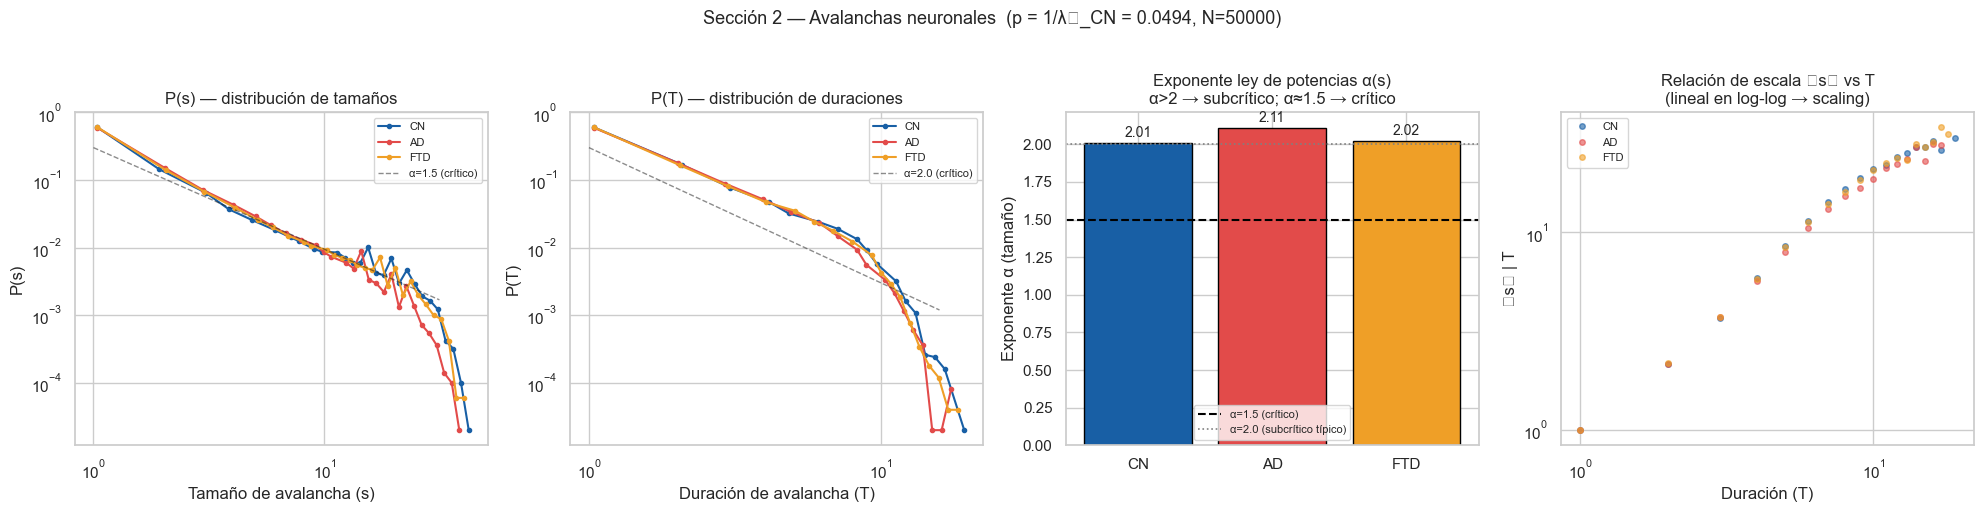

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# P(s) log-log
ax = axes[0]
for g in DIAG_ORD:
    s    = avalanche_data[g]['sizes']
    bins = np.logspace(0, np.log10(max(s.max(), 2) + 1), 50)
    vals, edges = np.histogram(s, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = vals > 0
    ax.plot(centers[mask], vals[mask] / vals[mask].sum(),
            'o-', color=COLORS[g], label=g, markersize=3, linewidth=1.5)
# Referencia: ley de potencias α=1.5
x_ref = np.logspace(0, 1.5, 30)
ax.plot(x_ref, 0.3 * x_ref**-1.5, 'k--', linewidth=1, alpha=0.5, label='α=1.5 (crítico)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Tamaño de avalancha (s)'); ax.set_ylabel('P(s)')
ax.set_title('P(s) — distribución de tamaños')
ax.legend(fontsize=8)

# P(T) log-log
ax = axes[1]
for g in DIAG_ORD:
    T    = avalanche_data[g]['durations']
    bins = np.logspace(0, np.log10(max(T.max(), 2) + 1), 40)
    vals, edges = np.histogram(T, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = vals > 0
    ax.plot(centers[mask], vals[mask] / vals[mask].sum(),
            'o-', color=COLORS[g], label=g, markersize=3, linewidth=1.5)
x_ref = np.logspace(0, 1.2, 30)
ax.plot(x_ref, 0.3 * x_ref**-2.0, 'k--', linewidth=1, alpha=0.5, label='α=2.0 (crítico)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Duración de avalancha (T)'); ax.set_ylabel('P(T)')
ax.set_title('P(T) — distribución de duraciones')
ax.legend(fontsize=8)

# Barplot α(s)
ax = axes[2]
alpha_vals = [pl_results[g]['alpha_s'] for g in DIAG_ORD]
bars = ax.bar(DIAG_ORD, alpha_vals, color=[COLORS[g] for g in DIAG_ORD], edgecolor='black')
ax.axhline(1.5, color='black',  linestyle='--', linewidth=1.5, label='α=1.5 (crítico)')
ax.axhline(2.0, color='gray',   linestyle=':',  linewidth=1.2, label='α=2.0 (subcrítico típico)')
ax.set_ylabel('Exponente α (tamaño)')
ax.set_title('Exponente ley de potencias α(s)\nα>2 → subcrítico; α≈1.5 → crítico')
ax.legend(fontsize=8)
for bar, val in zip(bars, alpha_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# <s> vs T (scaling relation)
ax = axes[3]
for g in DIAG_ORD:
    s = avalanche_data[g]['sizes']
    T = avalanche_data[g]['durations']
    T_u = np.unique(T)
    s_m = [s[T == t].mean() for t in T_u]
    ax.plot(T_u, s_m, 'o', color=COLORS[g], label=g, alpha=0.6, markersize=4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Duración (T)'); ax.set_ylabel('⟨s⟩ | T')
ax.set_title('Relación de escala ⟨s⟩ vs T\n(lineal en log-log → scaling)')
ax.legend(fontsize=8)

plt.suptitle(f'Sección 2 — Avalanchas neuronales  (p = 1/λ₁_CN = {p_crit:.4f}, N={N_AVALANCHAS})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 's2_avalanchas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 3 — Susceptibilidad de percolación

La teoría de percolación predice que al **umbral crítico de percolación** $p_c$ ocurre:
- $S_1$ (componente gigante) empieza a crecer rápidamente.
- $S_2$ (segundo componente más grande) alcanza su **máximo** — es el indicador más nítido de $p_c$.
- $\chi = S_2^2 / N$ diverge en redes infinitas; en redes finitas tiene un **pico claro**.

### ¿Qué esperar?
- **χ debe tener un pico visible** en alguna proporción intermedia. Si χ es siempre máxima en el valor mínimo del rango testeado, la transición ocurre por debajo de ese rango — necesitás extender hacia densidades menores.
- Para redes con hubs (como redes cerebrales), el componente gigante emerge a **densidades mucho menores** que en grafos aleatorios (ER critica a grado medio = 1, i.e., prop ≈ 0.9%). El cerebro puede perco​lar incluso a prop < 0.5%.
- Se usa una **grilla fina** (0.2%–3.0%) donde se espera la transición, más una grilla gruesa hasta 20% para contexto.

### Corrección respecto a versión anterior
La versión anterior usaba proporciones 2%–50% y siempre encontraba $T_c = 0.02$ (mínimo del rango). Esto ocurría porque las redes cerebrales con hubs ya tienen un componente gigante establecido al 2% de densidad. La grilla fina (< 2%) corrige esto.

In [10]:
# Grilla fina en la región donde ocurre la transición (<3%) + gruesa para contexto
PROPS_FINE   = np.arange(0.002, 0.032, 0.002)   # 0.2% a 3.0%, paso 0.2%
PROPS_COARSE = np.arange(0.040, 0.210, 0.010)   # 4.0% a 20.0%, paso 1.0%
PROPS_PERC   = np.round(np.concatenate([PROPS_FINE, PROPS_COARSE]), 3)
N_ROI = 116

print(f'Rango de proporciones: {PROPS_PERC[0]:.3f} a {PROPS_PERC[-1]:.3f}  ({len(PROPS_PERC)} valores)')
print('Iniciando análisis de percolación por sujeto...')

perc_records = []

for idx, row in meta_df.iterrows():
    fc_z = np.load(FC_DIR / f"{row['MRI_ID']}_fc_z.npy")

    for prop in PROPS_PERC:
        B = threshold_proportional(fc_z, prop)
        G = nx.from_numpy_array(B)
        comps = sorted(nx.connected_components(G), key=len, reverse=True)

        S1  = len(comps[0]) / N_ROI if comps else 0.0
        S2  = len(comps[1]) / N_ROI if len(comps) >= 2 else 0.0
        chi = (S2 ** 2) / N_ROI

        perc_records.append({
            'MRI_ID': row['MRI_ID'], 'diagnosis': row['diagnosis'],
            'prop': prop, 'S1': S1, 'S2': S2, 'chi': chi,
        })

    if (idx + 1) % 300 == 0:
        print(f'  [{idx+1}/{len(meta_df)}] sujetos procesados...')

perc_df = pd.DataFrame(perc_records)
print(f'Registros totales: {len(perc_df)}')

Rango de proporciones: 0.002 a 0.200  (32 valores)
Iniciando análisis de percolación por sujeto...
  [300/1327] sujetos procesados...
  [600/1327] sujetos procesados...
  [900/1327] sujetos procesados...
  [1200/1327] sujetos procesados...
Registros totales: 42464


In [11]:
# Promediar por grupo ± SEM
perc_agg = (
    perc_df
    .groupby(['diagnosis', 'prop'])[['S1', 'S2', 'chi']]
    .agg(['mean', 'sem'])
    .reset_index()
)
perc_agg.columns = ['diagnosis', 'prop',
                    'S1_mean', 'S1_sem', 'S2_mean', 'S2_sem', 'chi_mean', 'chi_sem']

# Umbral crítico: prop donde chi_mean es máximo
chi_peak = {}
chi_peak_val = {}
for g in DIAG_ORD:
    sub = perc_agg[perc_agg.diagnosis == g]
    idx_max = sub['chi_mean'].idxmax()
    chi_peak[g]     = sub.loc[idx_max, 'prop']
    chi_peak_val[g] = sub.loc[idx_max, 'chi_mean']

print('Umbral crítico de percolación (prop donde χ es máximo):')
for g in DIAG_ORD:
    boundary = ' ← en borde inferior, transición por debajo del rango' if chi_peak[g] == PROPS_PERC[0] else ''
    print(f'  {g}: prop_c = {chi_peak[g]:.3f}  χ_max = {chi_peak_val[g]:.5f}{boundary}')

Umbral crítico de percolación (prop donde χ es máximo):
  CN: prop_c = 0.020  χ_max = 0.00008
  AD: prop_c = 0.020  χ_max = 0.00011
  FTD: prop_c = 0.018  χ_max = 0.00009


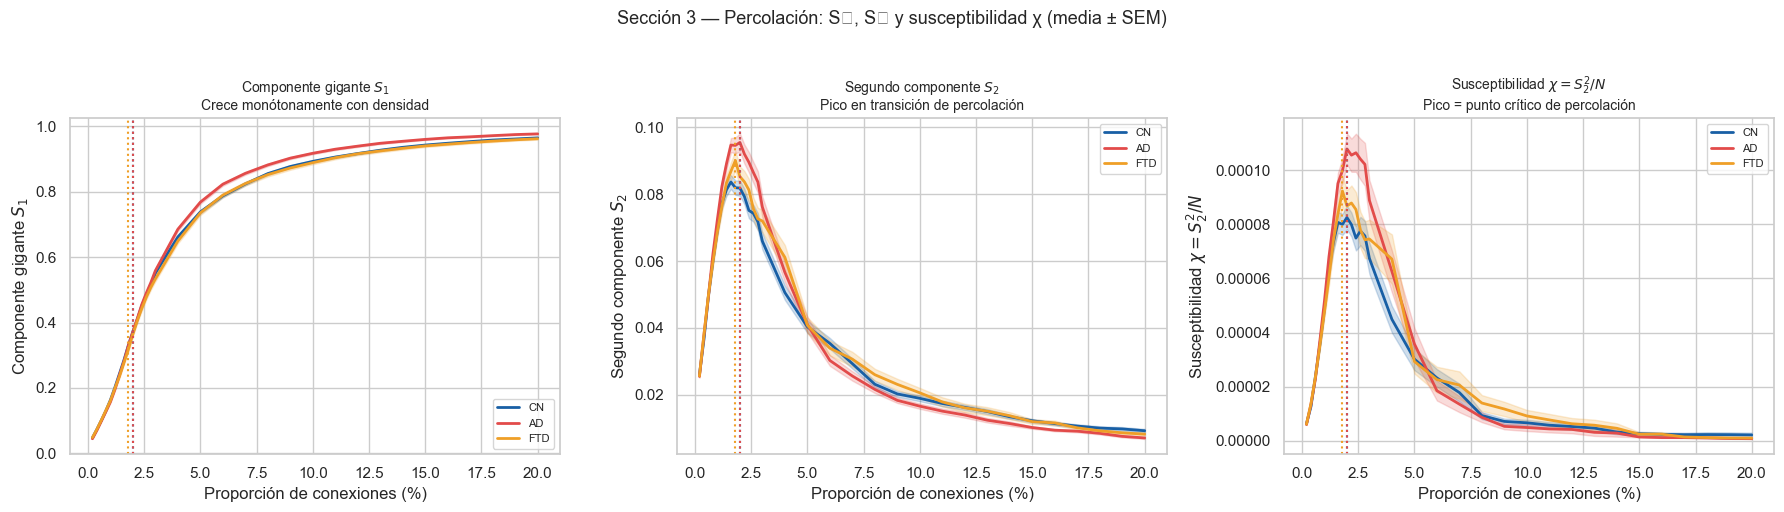

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_p = [
    ('S1', 'Componente gigante $S_1$', 'Crece monótonamente con densidad'),
    ('S2', 'Segundo componente $S_2$', 'Pico en transición de percolación'),
    ('chi', 'Susceptibilidad $\\chi = S_2^2/N$', 'Pico = punto crítico de percolación'),
]

for ax, (met, label, subtext) in zip(axes, metrics_p):
    for g in DIAG_ORD:
        sub = perc_agg[perc_agg.diagnosis == g]
        ax.plot(sub['prop'] * 100, sub[f'{met}_mean'], color=COLORS[g], label=g, linewidth=2)
        ax.fill_between(
            sub['prop'] * 100,
            sub[f'{met}_mean'] - sub[f'{met}_sem'],
            sub[f'{met}_mean'] + sub[f'{met}_sem'],
            color=COLORS[g], alpha=0.2
        )
    for g in DIAG_ORD:
        ax.axvline(chi_peak[g] * 100, color=COLORS[g], linestyle=':', linewidth=1.5)
    ax.set_xlabel('Proporción de conexiones (%)')
    ax.set_ylabel(label)
    ax.set_title(f'{label}\n{subtext}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Sección 3 — Percolación: S₁, S₂ y susceptibilidad χ (media ± SEM)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 's3_percolacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 4 — Branching Ratio (σ)

El branching ratio σ mide cuántos nodos activa en promedio cada nodo activo en la siguiente generación:

$$\sigma = \frac{\text{activaciones totales en generación } t+1}{\text{activaciones totales en generación } t}$$

### Estimador corregido (sin sesgo de supervivencia)

**Problema de la versión anterior:** El estimador `mean(n_{t+1}/n_t)` promedia solo sobre generaciones donde la avalancha sobrevive, excluyendo sistemáticamente los eventos de extinción (ratio = 0). Esto inflaba σ artificialmente de ~0.57 a ~1.23.

**Estimador correcto:**
$$\sigma = \frac{\sum_{\text{avalanchas}} \sum_t n_{t+1}}{\sum_{\text{avalanchas}} \sum_t n_t}$$

Este estimador incluye la última generación de cada avalancha como padres que producen 0 hijos (extinción), eliminando el sesgo.

### ¿Qué esperar?
- σ_teórico = $k_{medio} \times p \approx 0.57$ (subcrítico) con los parámetros actuales.
- Las diferencias entre grupos reflejan diferencias topológicas a igual densidad.
- AD con menor λ₁ debería tener distribución de grados más homogénea → σ ligeramente distinto de CN.

In [13]:
np.random.seed(42)
N_BOOTSTRAP = 1000

def compute_branching_ratio(generations: list) -> float:
    """σ = Σ(n_{t+1}) / Σ(n_t)  — estimador sin sesgo de supervivencia.
    
    Incluye la extinción: la última generación de cada avalancha contribuye
    sus nodos como 'padres' que producen 0 hijos, siendo contada en el
    denominador pero no en el numerador.
    """
    total_offspring = 0
    total_parents   = 0
    for gen in generations:
        for t in range(len(gen) - 1):
            total_offspring += gen[t + 1]
            total_parents   += gen[t]
        # Última generación: todos los nodos activos mueren (0 offspring)
        total_parents += gen[-1]
    return total_offspring / total_parents if total_parents > 0 else np.nan


branching_results = {}

for g in DIAG_ORD:
    gens      = avalanche_data[g]['generations']
    sigma_obs = compute_branching_ratio(gens)

    # IC por bootstrapping sobre las N_AVALANCHAS avalanchas
    indices     = np.arange(len(gens))
    boot_sigmas = []
    for _ in range(N_BOOTSTRAP):
        boot_idx  = np.random.choice(indices, size=len(indices), replace=True)
        boot_gens = [gens[i] for i in boot_idx]
        boot_sigmas.append(compute_branching_ratio(boot_gens))

    ci_low  = np.percentile(boot_sigmas, 2.5)
    ci_high = np.percentile(boot_sigmas, 97.5)
    branching_results[g] = {'sigma': sigma_obs, 'ci_low': ci_low, 'ci_high': ci_high}

    # σ teórico para comparación
    k_med  = adj_mean[g].sum(axis=0).mean()
    s_teor = k_med * p_crit
    print(f'{g}: σ_obs={sigma_obs:.4f}  IC95%[{ci_low:.4f},{ci_high:.4f}]  '
          f'σ_teor={s_teor:.4f}  [diferencia={sigma_obs-s_teor:+.4f}]')

CN: σ_obs=0.6671  IC95%[0.6628,0.6712]  σ_teor=0.5677  [diferencia=+0.0994]
AD: σ_obs=0.6284  IC95%[0.6238,0.6331]  σ_teor=0.5677  [diferencia=+0.0607]
FTD: σ_obs=0.6573  IC95%[0.6530,0.6619]  σ_teor=0.5677  [diferencia=+0.0897]


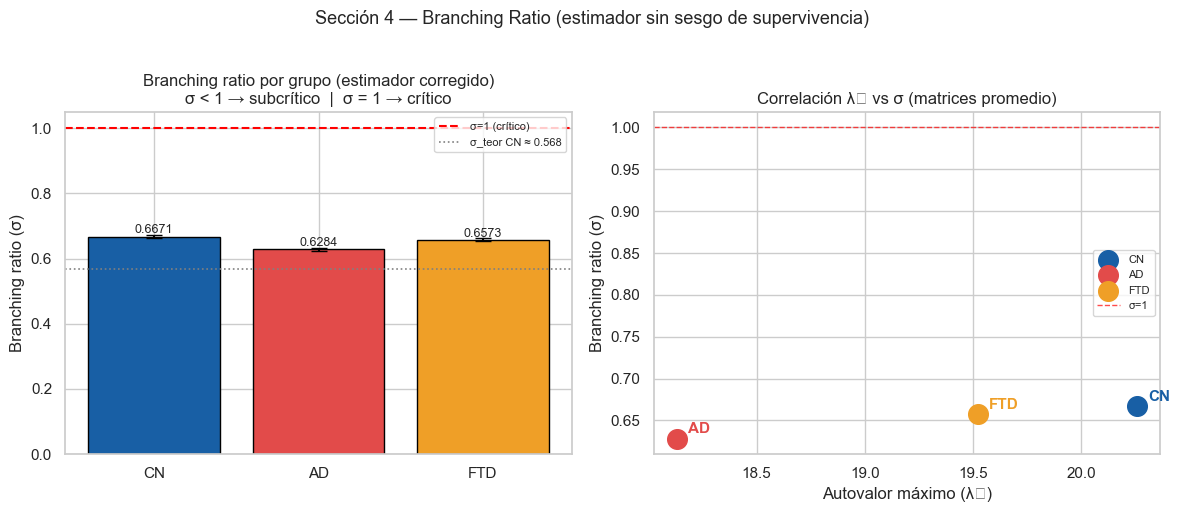

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot σ con IC
ax = axes[0]
sigmas    = [branching_results[g]['sigma']   for g in DIAG_ORD]
ci_lows   = [branching_results[g]['ci_low']  for g in DIAG_ORD]
ci_his    = [branching_results[g]['ci_high'] for g in DIAG_ORD]
yerr_low  = [s - l for s, l in zip(sigmas, ci_lows)]
yerr_high = [h - s for s, h in zip(sigmas, ci_his)]

bars = ax.bar(DIAG_ORD, sigmas, color=[COLORS[g] for g in DIAG_ORD], edgecolor='black')
ax.errorbar(DIAG_ORD, sigmas, yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=6, linewidth=1.5)
ax.axhline(1.0, color='red',   linestyle='--', linewidth=1.5, label='σ=1 (crítico)')
ax.axhline(p_crit * adj_mean['CN'].sum(axis=0).mean(), color='gray',
           linestyle=':', linewidth=1.2, label=f'σ_teor CN ≈ {p_crit*adj_mean["CN"].sum(axis=0).mean():.3f}')
ax.set_ylabel('Branching ratio (σ)')
ax.set_title('Branching ratio por grupo (estimador corregido)\nσ < 1 → subcrítico  |  σ = 1 → crítico')
ax.legend(fontsize=8)
for bar, val in zip(bars, sigmas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# λ₁ vs σ
ax = axes[1]
for g in DIAG_ORD:
    ax.scatter(lambda1_mean[g], branching_results[g]['sigma'],
               color=COLORS[g], s=200, zorder=5, label=g)
    ax.annotate(g, (lambda1_mean[g], branching_results[g]['sigma']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=11, color=COLORS[g], fontweight='bold')
ax.axhline(1.0, color='red',  linestyle='--', linewidth=1, alpha=0.7, label='σ=1')
ax.set_xlabel('Autovalor máximo (λ₁)')
ax.set_ylabel('Branching ratio (σ)')
ax.set_title('Correlación λ₁ vs σ (matrices promedio)')
ax.legend(fontsize=8)

plt.suptitle('Sección 4 — Branching Ratio (estimador sin sesgo de supervivencia)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 's4_branching_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Análisis estadístico (métricas individuales)

Se comparan λ₁, S₂_peak, χ_peak y umbral crítico entre CN, AD y FTD con Kruskal-Wallis y post-hoc Mann-Whitney con corrección FDR (Benjamini-Hochberg). Se reporta el tamaño de efecto rank-biserial r.

In [20]:
# Extraer S2_peak, chi_peak y umbral crítico por sujeto
subj_perc = []
for sub_id in meta_df['MRI_ID']:
    sub_data = perc_df[perc_df['MRI_ID'] == sub_id]
    idx_s2   = sub_data['S2'].idxmax()
    idx_chi  = sub_data['chi'].idxmax()
    subj_perc.append({
        'MRI_ID':             sub_id,
        'S2_peak':            sub_data.loc[idx_s2,  'S2'],
        'chi_peak':           sub_data.loc[idx_chi, 'chi'],
        'critical_threshold': sub_data.loc[idx_chi, 'prop'],
    })

metrics_indiv = (
    lambda1_df[['MRI_ID', 'diagnosis', 'lambda1', 'lambda1_norm']]
    .merge(pd.DataFrame(subj_perc), on='MRI_ID')
)
metrics_indiv.to_csv(RES_DIR / 'metricas_criticalidad.csv', index=False)
print(f'Tabla guardada: {len(metrics_indiv)} sujetos')
print(metrics_indiv.groupby('diagnosis')[['lambda1', 'lambda1_norm', 'S2_peak', 'chi_peak', 'critical_threshold']]
      .describe().round(4))

Tabla guardada: 1327 sujetos
          lambda1                                                       \
            count     mean     std      min      25%      50%      75%   
diagnosis                                                                
AD          468.0  20.2294  2.6757  14.1094  18.2876  20.0742  21.9300   
CN          555.0  20.9756  3.0993  14.3893  18.7525  20.7521  22.8156   
FTD         304.0  20.9812  2.9734  14.4243  18.7915  20.7210  23.1285   

                   lambda1_norm          ... chi_peak          \
               max        count    mean  ...      75%     max   
diagnosis                                ...                    
AD         29.2905        468.0  1.6279  ...   0.0003  0.0016   
CN         29.5482        555.0  1.6879  ...   0.0003  0.0015   
FTD        30.8740        304.0  1.6884  ...   0.0003  0.0012   

          critical_threshold                                                    
                       count    mean     std    min   

In [21]:
def rank_biserial(x, y):
    nx_, ny_ = len(x), len(y)
    U, _ = mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * U) / (nx_ * ny_)

stat_metrics = ['lambda1', 'lambda1_norm', 'S2_peak', 'chi_peak', 'critical_threshold']
pairs        = list(combinations(DIAG_ORD, 2))
stat_rows    = []

print('═' * 75)
for met in stat_metrics:
    groups = [metrics_indiv.loc[metrics_indiv.diagnosis == g, met].dropna() for g in DIAG_ORD]
    H, p_kw = kruskal(*groups)
    print(f'\n{met}:  Kruskal-Wallis H={H:.2f}, p={p_kw:.4e}')

    pvals = []
    for d1, d2 in pairs:
        g1 = metrics_indiv.loc[metrics_indiv.diagnosis == d1, met].dropna()
        g2 = metrics_indiv.loc[metrics_indiv.diagnosis == d2, met].dropna()
        _, p = mannwhitneyu(g1, g2, alternative='two-sided')
        pvals.append(p)

    _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

    for (d1, d2), p_raw, p_fdr in zip(pairs, pvals, pvals_fdr):
        g1 = metrics_indiv.loc[metrics_indiv.diagnosis == d1, met].dropna()
        g2 = metrics_indiv.loc[metrics_indiv.diagnosis == d2, met].dropna()
        r  = rank_biserial(g1.values, g2.values)
        sig = ' *' if p_fdr < 0.05 else ''
        print(f'  {d1} vs {d2}: p_FDR={p_fdr:.4f}{sig}  r={r:.3f}')
        stat_rows.append({
            'metric': met, 'group1': d1, 'group2': d2,
            'H_kruskal': round(H, 3), 'p_kruskal': round(p_kw, 6),
            'p_raw': round(pvals[pairs.index((d1, d2))], 5),
            'p_FDR': round(p_fdr, 5),
            'rank_biserial_r': round(r, 3),
            'significant_FDR05': p_fdr < 0.05,
        })

print('═' * 75)
stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(RES_DIR / 'estadisticas_criticalidad.csv', index=False)
print('\nTabla guardada en results/estadisticas_criticalidad.csv')

═══════════════════════════════════════════════════════════════════════════

lambda1:  Kruskal-Wallis H=16.64, p=2.4413e-04
  CN vs AD: p_FDR=0.0009 *  r=-0.131
  CN vs FTD: p_FDR=0.8654  r=0.007
  AD vs FTD: p_FDR=0.0012 *  r=0.142

lambda1_norm:  Kruskal-Wallis H=16.64, p=2.4413e-04
  CN vs AD: p_FDR=0.0009 *  r=-0.131
  CN vs FTD: p_FDR=0.8654  r=0.007
  AD vs FTD: p_FDR=0.0012 *  r=0.142

S2_peak:  Kruskal-Wallis H=13.89, p=9.6210e-04
  CN vs AD: p_FDR=0.0009 *  r=0.131
  CN vs FTD: p_FDR=0.5824  r=0.023
  AD vs FTD: p_FDR=0.0186 *  r=-0.106

chi_peak:  Kruskal-Wallis H=13.89, p=9.6210e-04
  CN vs AD: p_FDR=0.0009 *  r=0.131
  CN vs FTD: p_FDR=0.5824  r=0.023
  AD vs FTD: p_FDR=0.0186 *  r=-0.106

critical_threshold:  Kruskal-Wallis H=1.80, p=4.0562e-01
  CN vs AD: p_FDR=0.4791  r=0.044
  CN vs FTD: p_FDR=0.4791  r=0.041
  AD vs FTD: p_FDR=0.9720  r=0.001
═══════════════════════════════════════════════════════════════════════════

Tabla guardada en results/estadisticas_criticalidad

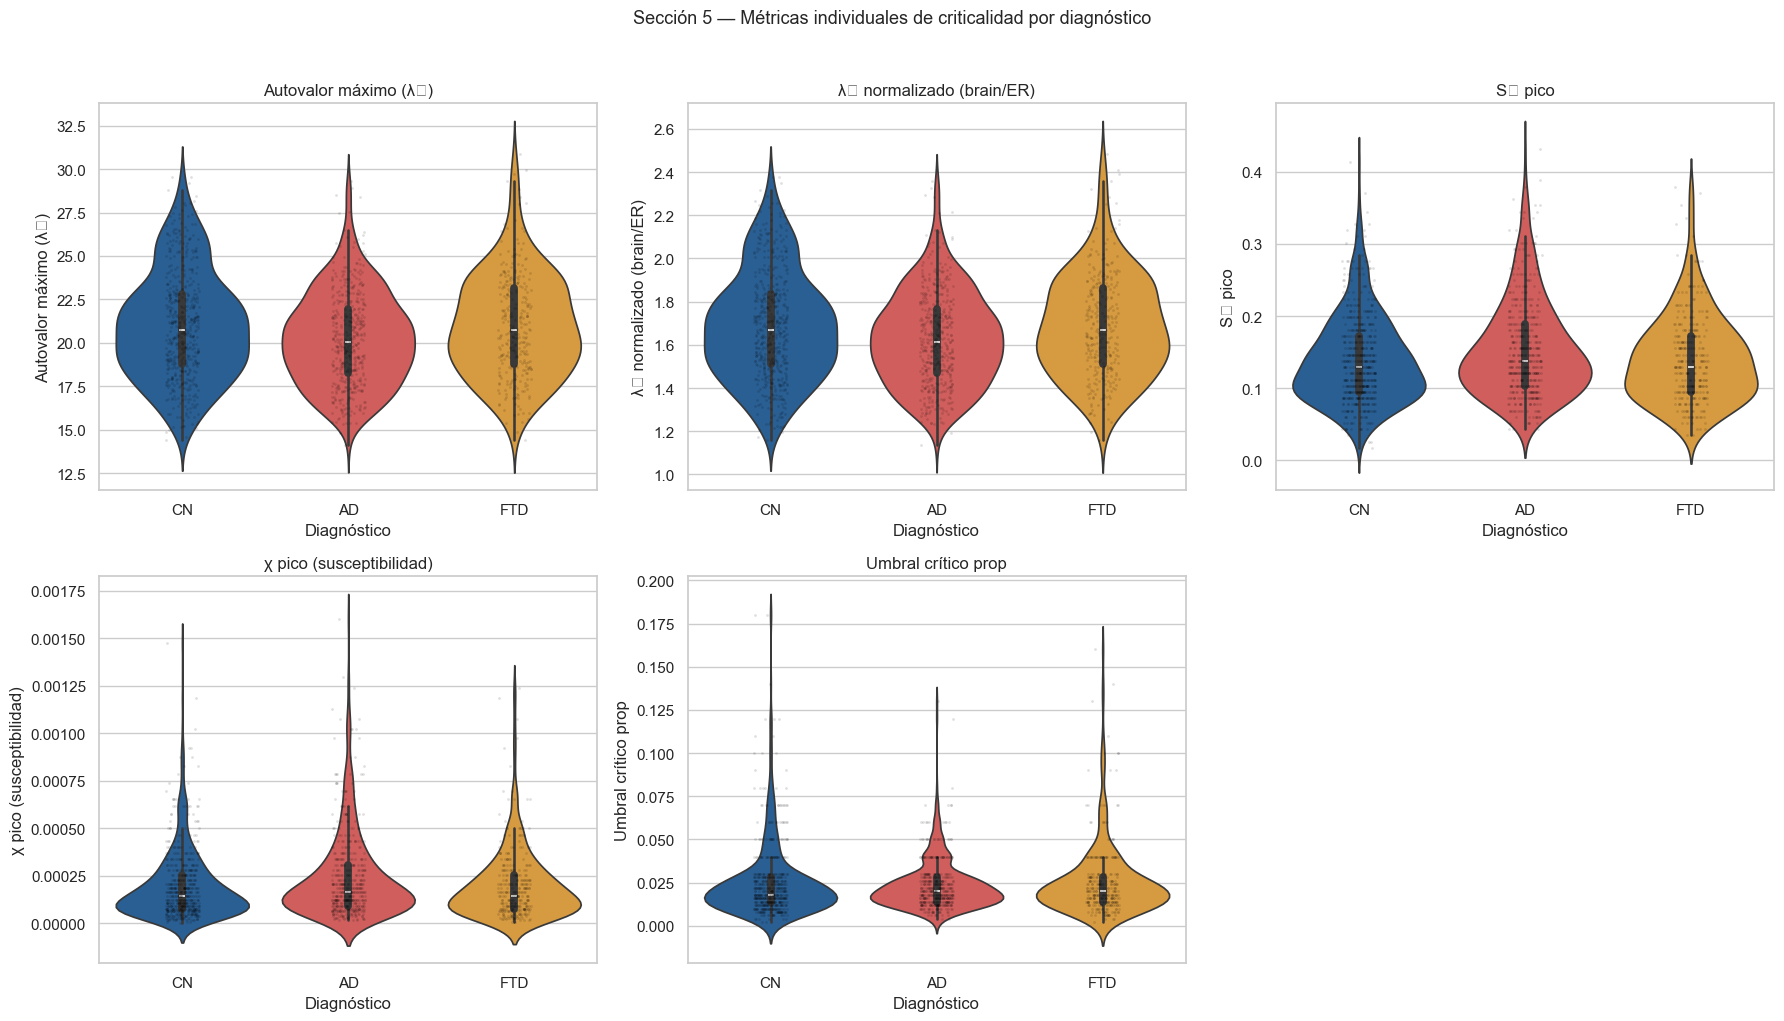

In [22]:
met_labels = {
    'lambda1':            'Autovalor máximo (λ₁)',
    'lambda1_norm':       'λ₁ normalizado (brain/ER)',
    'S2_peak':            'S₂ pico',
    'chi_peak':           'χ pico (susceptibilidad)',
    'critical_threshold': 'Umbral crítico prop',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.ravel()

for ax, met in zip(axes_flat, stat_metrics):
    sub = metrics_indiv[metrics_indiv.diagnosis.isin(DIAG_ORD)]
    sns.violinplot(data=sub, x='diagnosis', y=met, order=DIAG_ORD,
                   palette=COLORS, inner='box', ax=ax)
    sns.stripplot(data=sub, x='diagnosis', y=met, order=DIAG_ORD,
                  color='black', alpha=0.12, size=2, ax=ax)
    ax.set_title(met_labels[met])
    ax.set_xlabel('Diagnóstico')
    ax.set_ylabel(met_labels[met])

# Apagar eje sobrante
axes_flat[-1].set_visible(False)

plt.suptitle('Sección 5 — Métricas individuales de criticalidad por diagnóstico',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 's5_metricas_individuales.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 6 — Sensibilidad al umbral proporcional

Se verifica que las diferencias entre grupos en λ₁ sean robustas a la elección de PROP. Se repite el cálculo individual para PROP = 2% a 20% en pasos de 2%.

**Qué esperar:** Si la separación entre grupos (CN > FTD ≥ AD en λ₁) se mantiene a través de distintos PROP, la diferencia es robusta topológicamente y no un artefacto del umbral elegido.

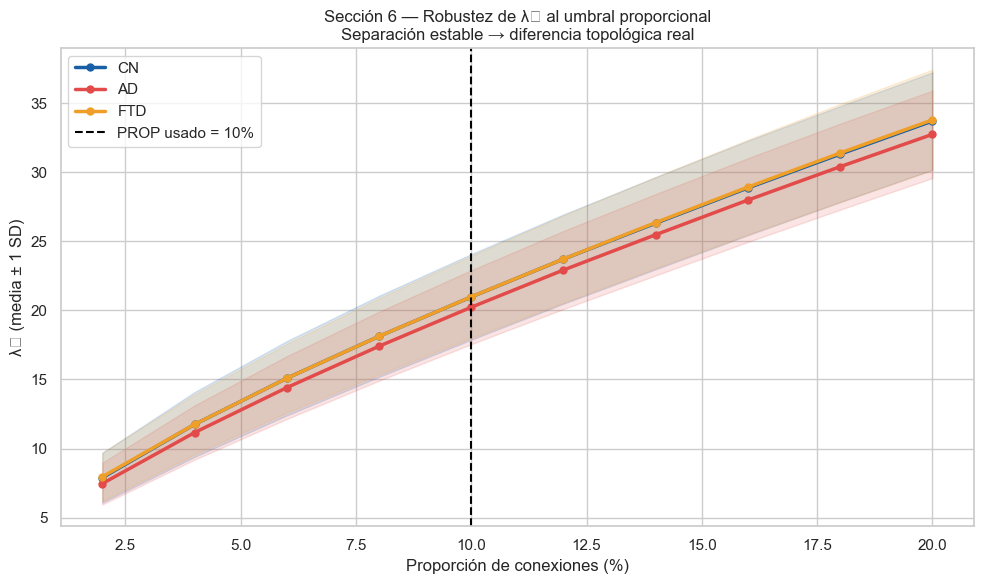

In [23]:
PROP_RANGE = np.round(np.arange(0.02, 0.22, 0.02), 2)   # 2% a 20%

sensitivity_records = []
for _, row in meta_df.iterrows():
    fc_z = np.load(FC_DIR / f"{row['MRI_ID']}_fc_z.npy")
    for prop in PROP_RANGE:
        B    = threshold_proportional(fc_z, prop)
        lam1 = np.linalg.eigvalsh(B)[-1]
        sensitivity_records.append({
            'MRI_ID': row['MRI_ID'], 'diagnosis': row['diagnosis'],
            'prop': prop, 'lambda1': lam1,
        })

sens_df  = pd.DataFrame(sensitivity_records)
sens_agg = (
    sens_df.groupby(['diagnosis', 'prop'])['lambda1']
    .agg(['mean', 'std'])
    .reset_index()
)
sens_agg.columns = ['diagnosis', 'prop', 'lambda1_mean', 'lambda1_sd']

fig, ax = plt.subplots(figsize=(10, 6))
for g in DIAG_ORD:
    sub = sens_agg[sens_agg.diagnosis == g]
    ax.plot(sub['prop'] * 100, sub['lambda1_mean'], color=COLORS[g],
            linewidth=2.5, label=g, marker='o', markersize=5)
    ax.fill_between(
        sub['prop'] * 100,
        sub['lambda1_mean'] - sub['lambda1_sd'],
        sub['lambda1_mean'] + sub['lambda1_sd'],
        color=COLORS[g], alpha=0.15
    )

ax.axvline(PROP * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'PROP usado = {PROP:.0%}')
ax.set_xlabel('Proporción de conexiones (%)')
ax.set_ylabel('λ₁ (media ± 1 SD)')
ax.set_title('Sección 6 — Robustez de λ₁ al umbral proporcional\n'
             'Separación estable → diferencia topológica real')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 's6_sensibilidad_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Resumen integrado

### Tabla de interpretación

| Métrica | Nivel | ¿Qué indica? | Resultado esperado | Significancia |
|---|---|---|---|---|
| λ₁ | Individual | Supercriticalidad topológica | CN > FTD ≥ AD | Kruskal-Wallis |
| λ₁_norm | Individual | Hub-concentración vs. red aleatoria | > 1 para todos los grupos | Idem |
| Δ (dyn. range) | Grupal | Capacidad dinámica de respuesta | AD > FTD > CN (si AD menos supercrítico) | Descriptivo |
| α(s) | Grupal | Régimen de avalanchas | > 2 → subcrítico (esperado con p = 1/λ₁_CN) | Descriptivo |
| σ (corregido) | Grupal | Propagación real de actividad | < 1 → subcrítico | Descriptivo |
| S₂_peak | Individual | Fragmentación de red | Refleja robustez del componente gigante | Mann-Whitney |
| χ_peak | Individual | Susceptibilidad a transición | Mayor → más cerca de T_c | Mann-Whitney |
| T_c (prop) | Individual | Umbral crítico de percolación | AD con T_c más bajo → fragmenta antes | Mann-Whitney |

### Notas sobre interpretación
- **σ y α son métricas grupales** (matrices promedio) — no reportar como individuales.
- **λ₁ >> 1 es esperado** con densidad del 10% en 116 nodos; el punto crítico del modelo (λ₁ = 1) no es alcanzable a estas densidades.
- **La percolación con grilla fina** (< 2%) es la corrección clave respecto a versiones anteriores del notebook donde siempre T_c caía en el borde del rango.

In [24]:
print('═' * 60)
print('RESUMEN CRITICALIDAD — resultados clave')
print('═' * 60)
print(f'N sujetos: {len(metrics_indiv)}  '
      f'(CN={( metrics_indiv.diagnosis=="CN").sum()}, '
      f'AD={(metrics_indiv.diagnosis=="AD").sum()}, '
      f'FTD={(metrics_indiv.diagnosis=="FTD").sum()})')
print()
print('λ₁ grupal (matrices promedio):')
for g in DIAG_ORD:
    print(f'  {g}: λ₁={lambda1_mean[g]:.3f}  λ₁_norm={er_null[g]["lambda1_norm"]:.3f}')
print()
print('Rango dinámico Δ:')
for g in DIAG_ORD:
    print(f'  {g}: Δ={delta_vals[g]:.2f} dB')
print()
print(f'Avalanchas (p={p_crit:.5f}, N={N_AVALANCHAS}):')
for g in DIAG_ORD:
    print(f'  {g}: α(s)={pl_results[g]["alpha_s"]:.3f}  '
          f'α(T)={pl_results[g]["alpha_T"]:.3f}  '
          f'⟨s⟩={avalanche_data[g]["sizes"].mean():.2f}')
print()
print('Branching ratio σ (estimador corregido):')
for g in DIAG_ORD:
    r = branching_results[g]
    print(f'  {g}: σ={r["sigma"]:.5f}  IC95%[{r["ci_low"]:.5f},{r["ci_high"]:.5f}]')
print()
print('Umbral crítico de percolación:')
for g in DIAG_ORD:
    print(f'  {g}: prop_c={chi_peak[g]:.3f} ({chi_peak[g]*100:.1f}%)')
print()
print('Figuras en:', FIG_DIR)
print('Resultados en:', RES_DIR)
print('═' * 60)

════════════════════════════════════════════════════════════
RESUMEN CRITICALIDAD — resultados clave
════════════════════════════════════════════════════════════
N sujetos: 1327  (CN=555, AD=468, FTD=304)

λ₁ grupal (matrices promedio):
  CN: λ₁=20.258  λ₁_norm=1.630
  AD: λ₁=18.130  λ₁_norm=1.459
  FTD: λ₁=19.523  λ₁_norm=1.571

Rango dinámico Δ:
  CN: Δ=16.05 dB
  AD: Δ=17.46 dB
  FTD: Δ=16.25 dB

Avalanchas (p=0.04936, N=50000):
  CN: α(s)=2.009  α(T)=2.395  ⟨s⟩=3.00
  AD: α(s)=2.109  α(T)=2.503  ⟨s⟩=2.69
  FTD: α(s)=2.020  α(T)=2.407  ⟨s⟩=2.92

Branching ratio σ (estimador corregido):
  CN: σ=0.66707  IC95%[0.66280,0.67117]
  AD: σ=0.62836  IC95%[0.62383,0.63312]
  FTD: σ=0.65734  IC95%[0.65298,0.66193]

Umbral crítico de percolación:
  CN: prop_c=0.020 (2.0%)
  AD: prop_c=0.020 (2.0%)
  FTD: prop_c=0.018 (1.8%)

Figuras en: figures\03_criticalidad
Resultados en: results
════════════════════════════════════════════════════════════
